<div style="
    background: #111827;
    color: white;
    padding: 35px;
    border-radius: 12px;
    margin-bottom: 25px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.15);
    font-family: Arial, sans-serif;
    ">

   <h1 style="
        margin: 0;
        font-size: 2.5rem;
        text-align: center;
        text-transform:uppercase;
        ">
        Análise histórica do Ibovespa dolarizado
   </h1>

   <hr style="
        border: none;
        height: 1px;
        background: rgba(255,255,255,0.2);
        margin: 25px 0 10px 0;
        ">

   <div style="
        display: flex;
        flex-direction:column;
        justify-content:center;
        align-items: center;
        flex-wrap: wrap;
        gap: 15px;
        font-size: 0.9rem;
        color: #94a3b8;
        ">
       <span style="font-weight: 500;">
            Autor: <strong style="color: white; font-weight: 600;">Wellington M. Santos</strong> - Cientista de Dados
       </span>
       <div style="display: flex; gap: 20px; font-weight: 500;justify-content:center">
            <a href="https://www.linkedin.com/in/wellington-moreira-santos" 
               target="_blank" 
               style="color:#93c5fd; text-decoration:none;">
               LinkedIn
            </a>
            <a href="mailto:wsantos08@hotmail.com" 
               style="color:#93c5fd; text-decoration:none;">
               Contato
            </a>
            <a href="https://github.com/esscova" 
               target="_blank" 
               style="color:#93c5fd; text-decoration:none;">
               GitHub
            </a>
       </div>
   </div>
</div>


## Introdução

O Ibovespa é o principal índice de referência do mercado acionário brasileiro. Analisado apenas
em reais, ele pode transmitir uma leitura distorcida: como a moeda brasileira sofre inflação e
desvalorização ao longo do tempo, o gráfico nominal tende a registrar sucessivas "máximas
históricas" que, na prática, refletem a perda de poder de compra da moeda, não necessariamente
uma valorização real do mercado.

Para contornar essa limitação, converto a série histórica do índice para dólares americanos.
A premissa é direta: 1 ponto do IBOV equivale a 1 real, então divido a pontuação diária do
índice pela cotação do dólar naquele mesmo dia. Esse ajuste permite enxergar o mercado
brasileiro pela ótica de um investidor internacional e identificar topos e fundos históricos
que a série em reais oculta.

Para isso, utilizo três bibliotecas: `yfinance` para coleta dos dados históricos diretamente
do Yahoo Finance, `pandas` para manipulação e alinhamento das séries temporais, e `matplotlib`
para construção dos gráficos comparativos.

Este notebook está organizado nas seguintes seções:

1. Imports e Configurações
2. Coleta e Inspeção dos Dados
3. Análise Exploratória
4. Visualizações
5. Conclusão e Considerações Finais
6. Referências

---

## 1. Imports e Configurações

Utilizo `yfinance` para baixar as séries históricas do IBOV e do câmbio USD/BRL diretamente
do Yahoo Finance. O `pandas` cuida da organização e do alinhamento temporal dos dados. O
`matplotlib` é responsável pela plotagem dos gráficos comparativos. O módulo `warnings` serve
apenas para suprimir avisos de bibliotecas que não afetam o resultado.


In [1]:
!pip install yfinance pandas matplotlib session_info -q


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
import session_info

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#94a3b8',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#f1f5f9',
    'grid.color':       '#334155',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

print('- BIBLIOTECAS CARREGADAS -')
print()
session_info.show()

- BIBLIOTECAS CARREGADAS -



---

## 2. Coleta e Inspeção dos Dados

Coleto as duas séries necessárias para a análise: o histórico do Ibovespa (`^BVSP`) e a
cotação diária do dólar frente ao real (`USDBRL=X`). O período começa em 1º de janeiro de
2007, data a partir da qual os dados de câmbio disponíveis no Yahoo Finance apresentam
cobertura confiável.

### 2.1 Download das séries

In [9]:
inicio = '2007-01-01'
fim    = pd.Timestamp.today().strftime('%Y-%m-%d')

ibov  = yf.download('^BVSP',    start=inicio, end=fim, multi_level_index=False, auto_adjust=False)
dolar = yf.download('USDBRL=X', start=inicio, end=fim, multi_level_index=False, auto_adjust=False)

print(f"IBOV  : {ibov.shape[0]} registros  | {ibov.index.min().date()} a {ibov.index.max().date()}")
print(f"Dólar : {dolar.shape[0]} registros  | {dolar.index.min().date()} a {dolar.index.max().date()}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

IBOV  : 4824 registros  | 2007-01-02 a 2026-06-25
Dólar : 5046 registros  | 2007-01-01 a 2026-06-26


As duas séries raramente têm exatamente o mesmo número de registros. O mercado de ações
e o mercado de câmbio operam em calendários ligeiramente diferentes, com feriados que não
coincidem. Esse desalinhamento precisa ser resolvido antes de qualquer cálculo.


### 2.2 Visão geral das séries brutas

In [12]:
ibov.tail()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-06-19,168576.0,168576.0,168787.0,167658.0,168279.0,4847900
2026-06-22,170370.0,170370.0,170750.0,168326.0,168334.0,8544200
2026-06-23,171259.0,171259.0,171720.0,168495.0,170367.0,7598800
2026-06-24,170507.0,170507.0,171342.0,169668.0,171256.0,9571200
2026-06-25,171990.0,171990.0,173277.0,170508.0,170508.0,7620600


In [13]:
dolar.tail()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-06-22,5.1514,5.1514,5.170100,5.124600,5.1510,0
2026-06-23,5.1565,5.1565,5.220700,5.135362,5.1562,0
2026-06-24,5.1977,5.1977,5.235600,5.175437,5.1985,0
2026-06-25,5.2075,5.2075,5.231500,5.183388,5.2076,0
2026-06-26,5.1941,5.1941,5.217068,5.161637,5.1940,0


Confirmo que ambas as séries trazem as colunas esperadas, incluindo `Adj Close`, que utilizarei
para os cálculos. Os índices são do tipo `DatetimeIndex`, o que facilita o alinhamento por data
na etapa seguinte.


### 2.3 Verificação de valores ausentes

In [14]:
print("Nulos IBOV:")
print(ibov.isnull().sum())

Nulos IBOV:
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64


In [16]:
print("Nulos Dólar:")
print(dolar.isnull().sum())

Nulos Dólar:
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64


Valores ausentes pontuais em séries financeiras costumam ocorrer em datas onde um dos mercados
operou e o outro não. O merge que realizo na próxima seção elimina esses casos automaticamente,
pois só mantém datas com registros em ambas as séries.

---

## 3. Análise Exploratória

Com as duas séries coletadas, preciso resolver o desalinhamento de datas antes de calcular o
IBOV dolarizado. Trabalho apenas com a coluna `Adj Close` de cada série e aplico um merge
interno para garantir que a divisão ocorra exclusivamente nos dias em que ambos os mercados,
o de ações e o de câmbio, estiveram em funcionamento.

### 3.1 Isolamento da coluna de fechamento ajustado

In [17]:
ibov_close  = ibov[['Adj Close']].rename(columns={'Adj Close': 'ibov'})
dolar_close = dolar[['Adj Close']].rename(columns={'Adj Close': 'usdbrl'})

print(ibov_close.shape)
print(dolar_close.shape)

(4824, 1)
(5046, 1)


### 3.2 Alinhamento por data (merge inner)

Realizo um merge do tipo `inner` entre as duas séries pelo índice de datas. Esse tipo de junção
descarta automaticamente qualquer data que não apareça nas duas séries ao mesmo tempo, garantindo
que cada linha do dataframe resultante tenha tanto o valor do IBOV quanto a cotação do dólar
para o mesmo dia.


In [18]:
antes_ibov  = len(ibov_close)
antes_dolar = len(dolar_close)

df = ibov_close.merge(dolar_close, left_index=True, right_index=True, how='inner')

print(f"Registros IBOV antes do merge        : {antes_ibov}")
print(f"Registros Dólar antes do merge       : {antes_dolar}")
print(f"Registros removidos pelo alinhamento : {max(antes_ibov, antes_dolar) - len(df)}")
print(f"Registros no dataframe final         : {len(df)}")

Registros IBOV antes do merge        : 4824
Registros Dólar antes do merge       : 5046
Registros removidos pelo alinhamento : 253
Registros no dataframe final         : 4793


In [19]:
df

,ibov,usdbrl
Date,,
2007-01-02,45383.0,2.1310
2007-01-03,44445.0,2.1345
2007-01-04,44020.0,2.1390
2007-01-05,42245.0,2.1470
2007-01-08,42830.0,2.1465
...,...,...
2026-06-19,168576.0,5.1815
2026-06-22,170370.0,5.1514
2026-06-23,171259.0,5.1565


O número de registros removidos representa dias em que apenas um dos mercados operou. A perda
é pequena em relação ao total e não compromete a análise. O dataframe resultante está pronto
para o cálculo.

### 3.3 Cálculo do IBOV dolarizado

Com as séries alinhadas, o cálculo é direto: divido o valor do IBOV em pontos (equivalente
a reais) pela cotação do dólar naquele dia. O resultado é a pontuação do índice expressa
em dólares americanos.


In [20]:
df['ibov_usd'] = df['ibov'] / df['usdbrl']
df.tail()

,ibov,usdbrl,ibov_usd
Date,,,
2026-06-19,168576.0,5.1815,32534.208504
2026-06-22,170370.0,5.1514,33072.562225
2026-06-23,171259.0,5.1565,33212.257260
2026-06-24,170507.0,5.1977,32804.317145
2026-06-25,171990.0,5.2075,33027.364499


A nova coluna `ibov_usd` representa o valor diário do índice em dólares. Verifico as primeiras
e últimas linhas para confirmar que os valores fazem sentido antes de passar para a visualização.



---


## 4. Visualizações

Construo dois gráficos. O primeiro mostra apenas a série dolarizada, para uma leitura direta
do comportamento do índice em dólares. O segundo é um painel comparativo, com o IBOV em reais
na parte superior e o IBOV em dólares na inferior, permitindo visualizar lado a lado como a
desvalorização cambial distorce a percepção de desempenho da bolsa.


### 4.1 IBOV em dólares

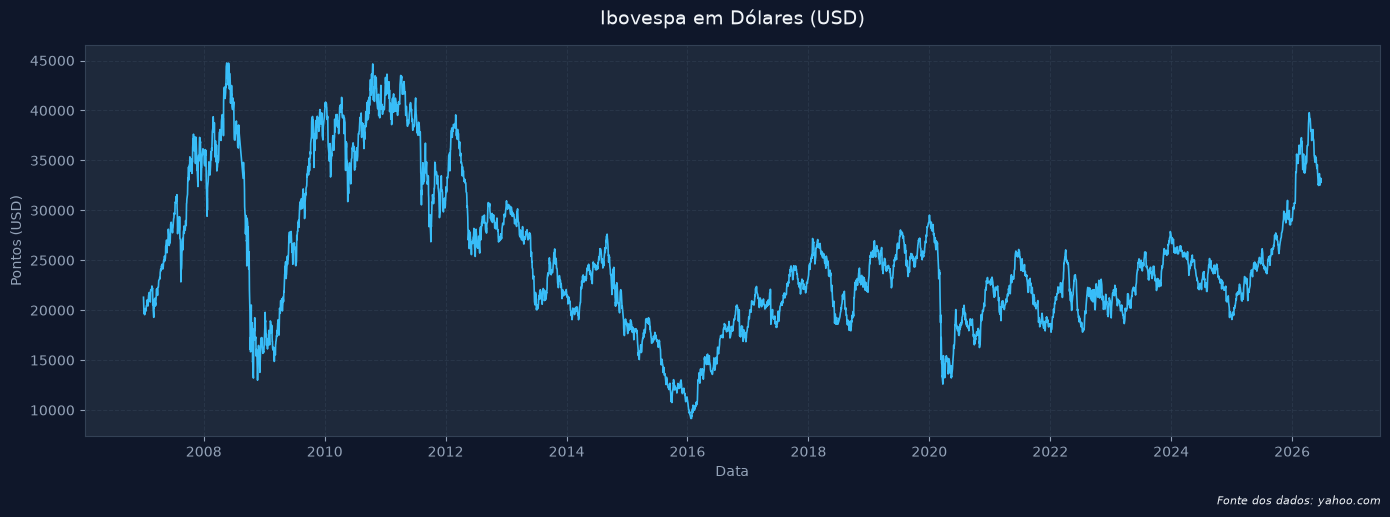

In [23]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df['ibov_usd'], color='#38bdf8', linewidth=1.2)
ax.set_title('Ibovespa em Dólares (USD)', fontsize=14, pad=15)
ax.set_xlabel('Data')
ax.set_ylabel('Pontos (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.grid(True)
fig.text(.99,
         -.02,
         'Fonte dos dados: yahoo.com',
         fontsize=8,
         style='italic',
         ha='right')
plt.tight_layout()
plt.show()

O gráfico em dólares revela um padrão bem diferente do que o gráfico em reais sugere. O topo
de 2008, período anterior à crise financeira global quando o dólar custava menos de R$ 2,00,
aparece como um patamar elevado que o índice ainda não voltou a superar em termos absolutos.
As "máximas históricas" nominais em reais, frequentemente noticiadas pela imprensa financeira,
não aparecem como tais nessa perspectiva.


### 4.2 Painel comparativo: IBOV em reais x IBOV em dólares


O painel comparativo torna evidente a diferença de narrativa entre as duas séries. No gráfico
superior, a trajetória em reais parece uma escalada contínua com poucos recuos expressivos. No
gráfico inferior, o IBOV em dólares mostra uma série com amplitude muito maior: o mercado
brasileiro, visto de fora, passou por períodos de forte deterioração que a série nominal em
reais ameniza visualmente. O topo de 2008 e os fundos de 2015 e 2020 ficam muito mais
pronunciados na versão dolarizada.

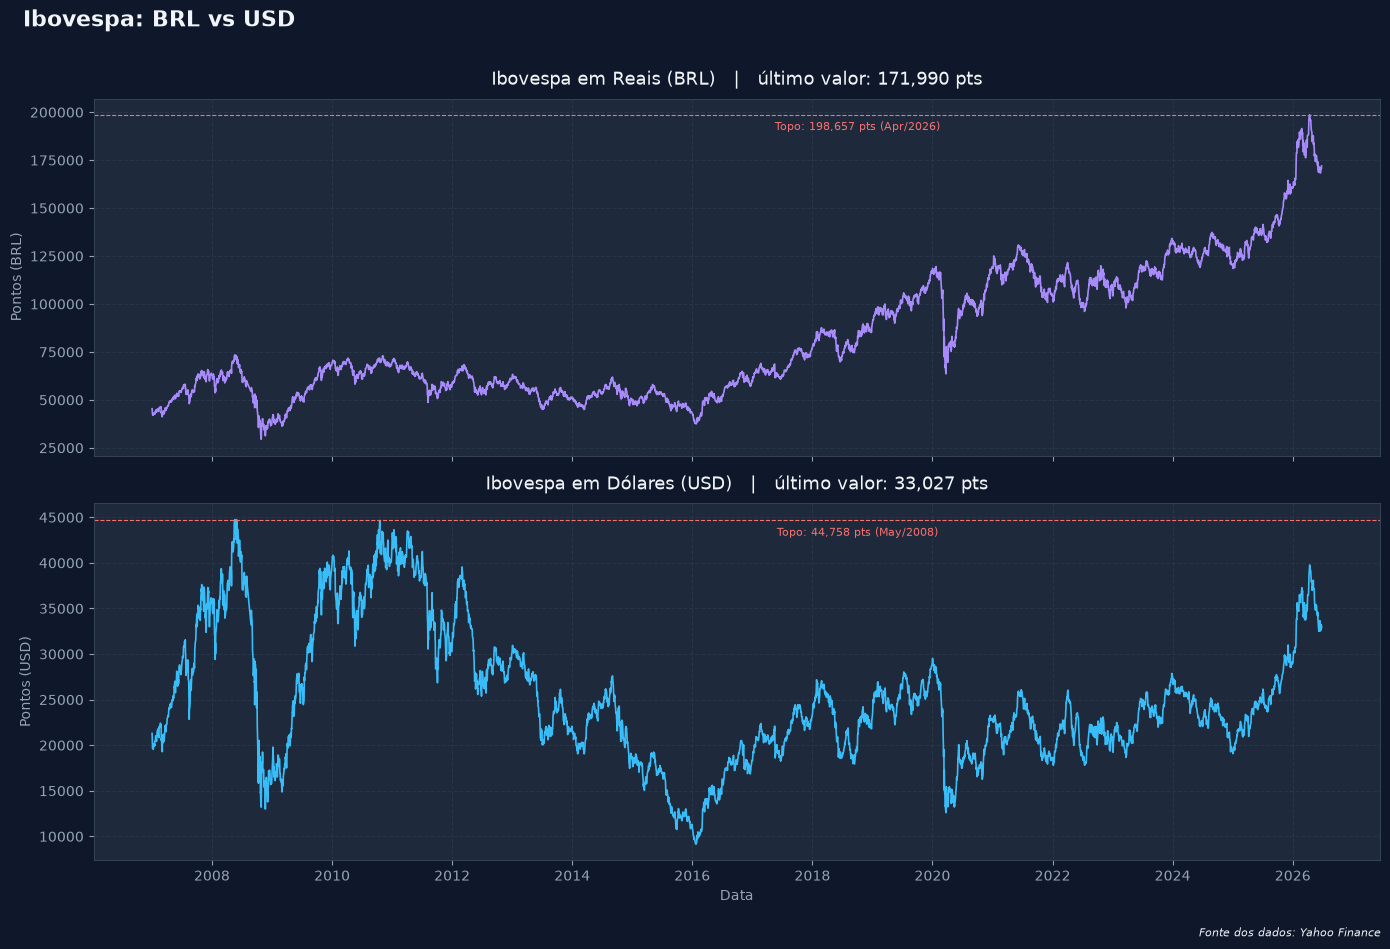

In [46]:
# topos históricos
topo_brl    = df['ibov'].max()
topo_brl_dt = df['ibov'].idxmax()
topo_usd    = df['ibov_usd'].max()
topo_usd_dt = df['ibov_usd'].idxmax()

# últimos valores
ultimo_brl = df['ibov'].iloc[-1]
ultimo_usd = df['ibov_usd'].iloc[-1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# BRL
ax1.plot(df.index, df['ibov'], color='#a78bfa', linewidth=1.2)
ax1.axhline(topo_brl, color='#f87171', linewidth=0.8, linestyle='--')
ax1.annotate(
    f'Topo: {topo_brl:,.0f} pts ({topo_brl_dt.strftime("%b/%Y")})',
    xy=(topo_brl_dt, topo_brl),
    xytext=(df.index[int(len(df) * 0.6)], topo_brl * 0.96),
    fontsize=8,
    color='#f87171',
    ha='center',
)
ax1.set_title(
    f'Ibovespa em Reais (BRL)   |   último valor: {ultimo_brl:,.0f} pts',
    fontsize=13, pad=10
)
ax1.set_ylabel('Pontos (BRL)')
ax1.grid(True)

# USD
ax2.plot(df.index, df['ibov_usd'], color='#38bdf8', linewidth=1.2)
ax2.axhline(topo_usd, color='#f87171', linewidth=0.8, linestyle='--')
ax2.annotate(
    f'Topo: {topo_usd:,.0f} pts ({topo_usd_dt.strftime("%b/%Y")})',
    xy=(topo_usd_dt, topo_usd),
    xytext=(df.index[int(len(df) * 0.6)], topo_usd * 0.96),
    fontsize=8,
    color='#f87171',
    ha='center',
)
ax2.set_title(
    f'Ibovespa em Dólares (USD)   |   último valor: {ultimo_usd:,.0f} pts',
    fontsize=13, pad=10
)
ax2.set_ylabel('Pontos (USD)')
ax2.set_xlabel('Data')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.grid(True)

fig.suptitle('Ibovespa: BRL vs USD', fontsize=16, y=1.01, x=.02, fontweight='bold', ha='left')
fig.text(.99, -.02, 'Fonte dos dados: Yahoo Finance', fontsize=8, style='italic', ha='right')
plt.tight_layout()
plt.savefig('ibov_brl_dol.png')
plt.show()

---


## 5. Conclusão e Considerações Finais

### 5.1 Síntese do Projeto

Neste notebook, construí a série histórica do Ibovespa expressa em dólares americanos a partir
de dados abertos do Yahoo Finance. O processo envolveu a coleta paralela de dois ativos, o
alinhamento das séries por data via merge interno para resolver o descompasso de calendários
entre os mercados, o cálculo da conversão e a construção de dois gráficos para comparação.


| Etapa                          | Detalhe                                      |
|-------------------------------|----------------------------------------------|
| Período analisado             | 01/01/2007 até 25/06/2026                          |
| Fonte dos dados               | Yahoo Finance via yfinance                   |
| Registros após alinhamento    | 4793                         |
| Topo histórico em BRL         | 198.657 pts                         |
| Topo histórico em USD         | 44.758  pts                        |
| Último valor em BRL           | 171.990 pts                        |
| Último valor em USD           | 33.027  pts                         |

### 5.2 O efeito cambial sobre a percepção de desempenho

O achado central deste projeto é o quanto a desvalorização do real distorce a leitura
do mercado acionário brasileiro. Em reais, o Ibovespa registrou sua máxima histórica
em abril de 2026, superando 197 mil pontos. Em dólares, esse mesmo momento corresponde
a cerca de 38 mil pontos, patamar ainda distante do topo de maio de 2008, quando o
índice atingiu mais de 42 mil pontos com o dólar abaixo de R$ 2,00.

A diferença de narrativa entre os dois gráficos é substancial: o que parece uma bolsa
em máxima histórica quando medida em reais é, sob a ótica internacional, um mercado
que ainda não recuperou o nível de quase duas décadas atrás. Esse contraste evidencia
que a avaliação do mercado brasileiro sem o ajuste cambial produz uma leitura
incompleta para qualquer análise comparativa com outros mercados globais.


### 5.3 Limitações e Considerações

- A análise usa o preço de fechamento ajustado do par `USDBRL=X` do Yahoo Finance, que pode
  apresentar pequenas divergências em relação às taxas oficiais do Banco Central do Brasil.
- A premissa de que 1 ponto do IBOV equivale a 1 real é uma convenção amplamente utilizada,
  mas é uma simplificação: o índice é calculado em pontos, não em reais diretamente.
- Feriados nacionais e bancários que afetam o mercado de câmbio mas não o de ações, e vice-versa,
  foram descartados pelo merge inner. Esse conjunto de dias não foi inspecionado individualmente.
- Nenhuma análise estatística formal foi realizada sobre as séries: sem teste de estacionariedade,
  sem decomposição de tendência e sazonalidade, sem modelagem.

Este notebook foi desenvolvido para fins educacionais e de composição de portfólio.

---

## 6. Referências

- Yahoo Finance: https://finance.yahoo.com
- Documentação yfinance: https://ranaroussi.github.io/yfinance
- Documentação pandas: https://pandas.pydata.org/docs
- Documentação matplotlib: https://matplotlib.org/stable/index.html
- Videoaula original: "Como dolarizar o gráfico histórico do IBOV" - Canal Trading com Dados
  (João Gabriel): https://youtu.be/VIYxNFyajy0?si=mUWk5hUyP6PUayXF

---

> Material desenvolvido para estudos e composição de portfólio a partir da videoaula
> [Trading com Dados - Como dolarizar o IBOV](https://youtu.be/VIYxNFyajy0?si=mUWk5hUyP6PUayXF),
> para o repositório [financas-quantitativas](https://github.com/esscova/financas-quantitativas/);
> com auxílio do Claude Anthropic para revisões e estruturação.